In [20]:
# Exploratory data analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv("Heart_Dataset_2.csv")
dataset.shape
dataset.head(5)
dataset.describe()
dataset.info()
dataset["target"].describe()
dataset["target"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   gender    303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


array([1, 0])

In [21]:
from sklearn.model_selection import train_test_split
predictors = dataset.drop("target",axis =1)
target = dataset["target"]

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(predictors, target, test_size = 0.20, random_state = 0)
X_train.shape
X_test.shape
Y_train.shape
Y_test.shape

(61,)

**NAIVE BAYES CLASSIFIER**

**Example 1**

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Create Gaussian Naive Bayes object
classifer = GaussianNB()
# Train model
model = classifer.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))


target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred,
target_names=target_names))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, Y_pred,
pos_label=2)
plt.show()

The accuracy is 85.24590163934425%
[[21  6]
 [ 3 31]]
              precision    recall  f1-score   support

     class 0       0.88      0.78      0.82        27
     class 1       0.84      0.91      0.87        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



C:\Users\Sumba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


**Example 2**

In [24]:
# Create Gaussian Naive Bayes object with prior probabilities of each class
classifer = GaussianNB(priors=[0.25, 0.75])
# Train model
model = classifer.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")

The accuracy is 80.32786885245902%


Further questions related to Naive Bayes

[[18  9]
 [ 3 31]]
              precision    recall  f1-score   support

     class 0       0.86      0.67      0.75        27
     class 1       0.78      0.91      0.84        34

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.79        61
weighted avg       0.81      0.80      0.80        61



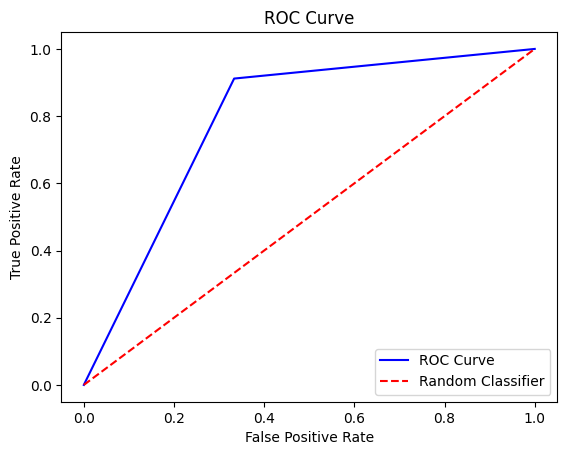

In [25]:
# Finding all the performance metrics on the heart dataset
print(confusion_matrix(Y_test, Y_pred))
target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred, target_names=target_names))

# FPR and ROC curve
fpr, tpr, thresholds = metrics.roc_curve(Y_test, Y_pred, pos_label=1)

# Plot the ROC curve
plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [26]:
# Test the naïve Bayes algorithm with prior probabilities (0.25, 0.75), (0.75, 0.25), and (0.5, 0.5) on heart dataset. Study the impact on performance metrics.

# testing on different probabilities

classifer1 = GaussianNB(priors=[0.75, 0.25])
# Train model
model = classifer1.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))
target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred, target_names=target_names))


The accuracy is 83.60655737704919%
[[24  3]
 [ 7 27]]
              precision    recall  f1-score   support

     class 0       0.77      0.89      0.83        27
     class 1       0.90      0.79      0.84        34

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [27]:
classifer3 = GaussianNB(priors=[0.5, 0.5])
# Train model
model = classifer3.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))
target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred, target_names=target_names))

The accuracy is 83.60655737704919%
[[21  6]
 [ 4 30]]
              precision    recall  f1-score   support

     class 0       0.84      0.78      0.81        27
     class 1       0.83      0.88      0.86        34

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [28]:
# Compare the Guassian implementation of naïve Bayes algorithm with Bernoulli and Multinomial on heart dataset. Study the impact on performance metrics.

from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Create Gaussian Naive Bayes object
classifer_Bernoulli = BernoulliNB()
# Train model
model = classifer_Bernoulli.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))


target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred,
target_names=target_names))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, Y_pred,
pos_label=2)
plt.show()


The accuracy is 81.9672131147541%
[[20  7]
 [ 4 30]]
              precision    recall  f1-score   support

     class 0       0.83      0.74      0.78        27
     class 1       0.81      0.88      0.85        34

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.81        61
weighted avg       0.82      0.82      0.82        61



C:\Users\Sumba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Create Gaussian Naive Bayes object
classifer_Multi = MultinomialNB()
# Train model
model = classifer_Multi.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))


target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred,
target_names=target_names))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, Y_pred,
pos_label=2)
plt.show()

The accuracy is 77.04918032786885%
[[19  8]
 [ 6 28]]
              precision    recall  f1-score   support

     class 0       0.76      0.70      0.73        27
     class 1       0.78      0.82      0.80        34

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



C:\Users\Sumba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


Implementing Naive Bayes Classifier on the Spambase dataset

In [30]:
# Exploratory data analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasett = pd.read_csv("spambase.csv")
datasett.shape
datasett.head(5)
datasett.describe()
datasett.info()
datasett["spam"].describe()
datasett["spam"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

array([1, 0])

In [31]:
from sklearn.model_selection import train_test_split
predictors = datasett.drop("spam",axis =1)
target = datasett["spam"]

In [32]:
X_train, X_test, Y_train, Y_test = train_test_split(predictors, target, test_size = 0.20, random_state = 0)
X_train.shape
X_test.shape
Y_train.shape
Y_test.shape

(921,)

In [33]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Create Gaussian Naive Bayes object
classifer = GaussianNB()
# Train model
model = classifer.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
print("The accuracy is "+str(metrics.accuracy_score(Y_test,Y_pred)*100)+"%")
print(confusion_matrix(Y_test, Y_pred))


target_names = ['class 0', 'class 1']
print(classification_report(Y_test, Y_pred,
target_names=target_names))
fpr, tpr, thresholds = metrics.roc_curve(Y_test, Y_pred,
pos_label=2)
plt.show()

The accuracy is 80.67318132464713%
[[386 152]
 [ 26 357]]
              precision    recall  f1-score   support

     class 0       0.94      0.72      0.81       538
     class 1       0.70      0.93      0.80       383

    accuracy                           0.81       921
   macro avg       0.82      0.82      0.81       921
weighted avg       0.84      0.81      0.81       921



C:\Users\Sumba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
